In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_train = pd.read_csv('train_data.csv')

In [ ]:
df_train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
# Calculate null rates for each column
null_rates = df_train.isnull().sum() / len(df_train) * 100
null_rates

,0
Item_Identifier,0.000000
Item_Weight,17.165317
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Identifier,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,28.276428
Outlet_Location_Type,0.000000


In [ ]:
unique_values = df_train['Item_Fat_Content'].unique()
num_unique_values = len(unique_values)

print(f"Number of unique values in 'Item_Fat_Content': {num_unique_values}")
print(f"Unique values: {unique_values}")

Number of unique values in 'Item_Fat_Content': 5
Unique values: ['Low Fat' 'Regular' 'low fat' 'LF' 'reg']


In [ ]:
unique_values = df_train['Item_Type'].unique()
num_unique_values = len(unique_values)

print(f"Number of unique values in 'Item_Type': {num_unique_values}")
print(f"Unique values: {unique_values}")

Number of unique values in 'Item_Type': 16
Unique values: ['Dairy' 'Soft Drinks' 'Meat' 'Fruits and Vegetables' 'Household'
 'Baking Goods' 'Snack Foods' 'Frozen Foods' 'Breakfast'
 'Health and Hygiene' 'Hard Drinks' 'Canned' 'Breads' 'Starchy Foods'
 'Others' 'Seafood']


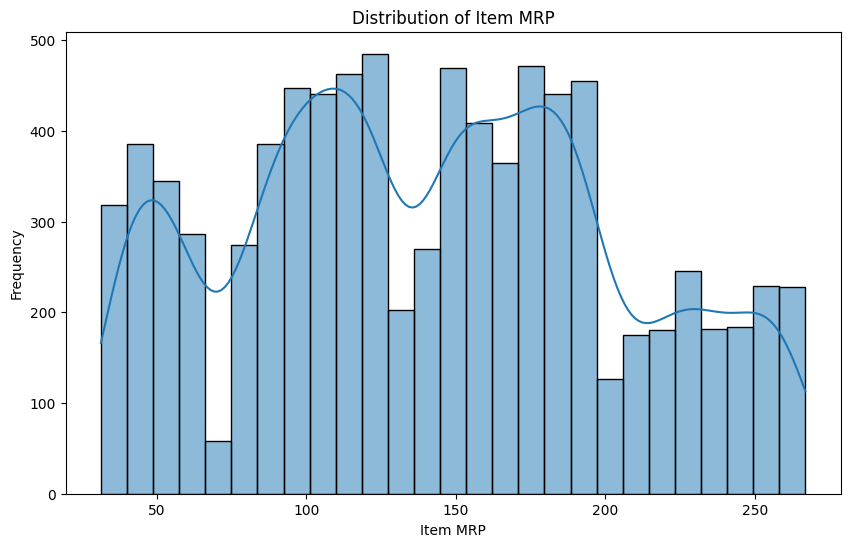

In [ ]:
# Assuming 'df_train' is already loaded as in the previous code

# Distribution of 'Item_MRP'
plt.figure(figsize=(10, 6))
sns.histplot(df_train['Item_MRP'], kde=True)  # Use a histogram with KDE
plt.title('Distribution of Item MRP')
plt.xlabel('Item MRP')
plt.ylabel('Frequency')
plt.show()


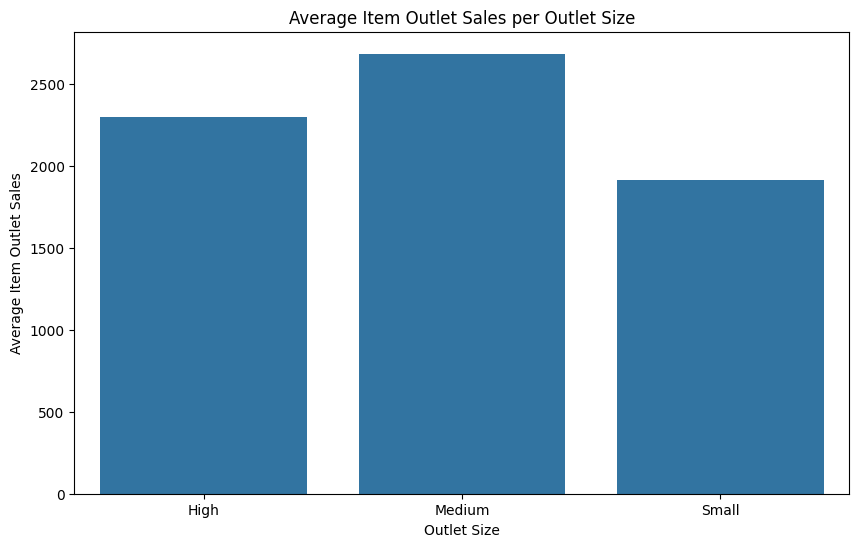

In [ ]:
# prompt: average item_outlet_sale as per outlet size plot a bar graph

# Calculate average 'Item_Outlet_Sales' for each 'Outlet_Size'
average_sales_by_size = df_train.groupby('Outlet_Size')['Item_Outlet_Sales'].mean()

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=average_sales_by_size.index, y=average_sales_by_size.values)
plt.title('Average Item Outlet Sales per Outlet Size')
plt.xlabel('Outlet Size')
plt.ylabel('Average Item Outlet Sales')
plt.show()

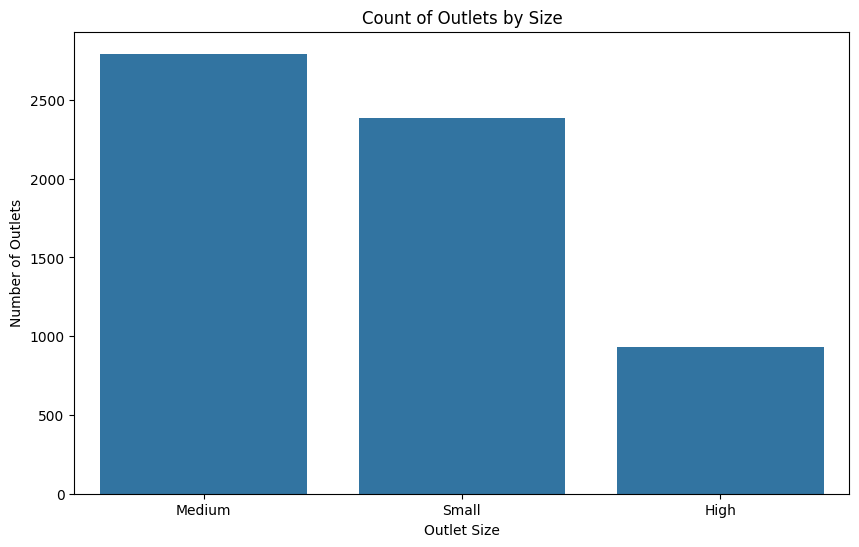

In [ ]:
# Assuming 'df_train' is already loaded as in the previous code

# Count the occurrences of each outlet size
outlet_size_counts = df_train['Outlet_Size'].value_counts()

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=outlet_size_counts.index, y=outlet_size_counts.values)
plt.title('Count of Outlets by Size')
plt.xlabel('Outlet Size')
plt.ylabel('Number of Outlets')
plt.show()

In [ ]:
# prompt: group by columns Outlet_Identifier	Outlet_Size	Outlet_Location_Type for the sum of item_outlet_sales and then convert the result bac to pandas df

# Group by specified columns and calculate the sum of 'Item_Outlet_Sales'
grouped_sales = df_train.groupby(['Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type'])['Item_Outlet_Sales'].sum()

# Convert the result back to a Pandas DataFrame
unique_outlet_df = grouped_sales.reset_index()

# Display the resulting DataFrame
unique_outlet_df


,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Item_Outlet_Sales
0,OUT013,High,Tier 3,2.142664e+06
1,OUT018,Medium,Tier 3,1.851823e+06
2,OUT019,Small,Tier 1,1.796941e+05
3,OUT027,Medium,Tier 3,3.453926e+06
4,OUT035,Small,Tier 2,2.268123e+06
5,OUT046,Small,Tier 1,2.118395e+06
6,OUT049,Medium,Tier 1,2.183970e+06


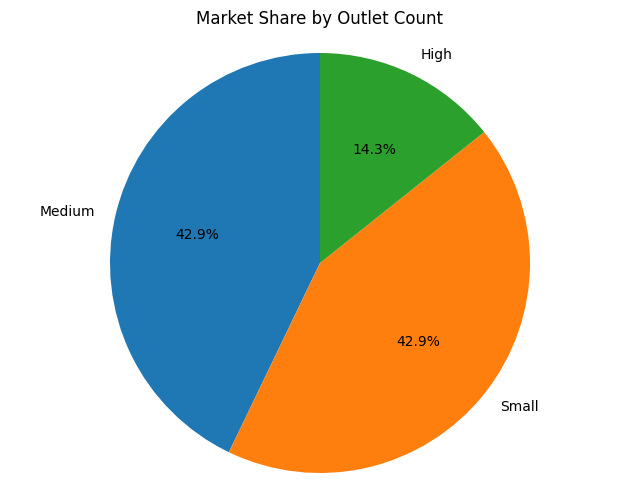

In [ ]:
outlet_size_counts = unique_outlet_df['Outlet_Size'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(outlet_size_counts, labels=outlet_size_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Market Share by Outlet Count')
plt.axis('equal')
plt.show()


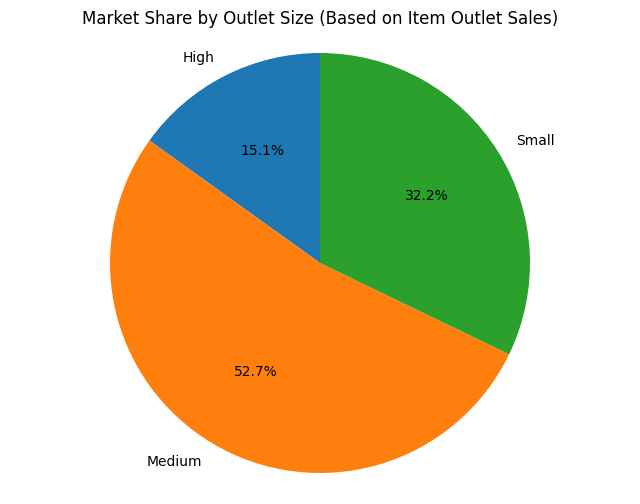

In [ ]:
# Group by 'Outlet_Size' and sum 'Item_Outlet_Sales'
outlet_sales_by_size = unique_outlet_df.groupby('Outlet_Size')['Item_Outlet_Sales'].sum()

# Create the pie chart
plt.figure(figsize=(8, 6))
plt.pie(outlet_sales_by_size, labels=outlet_sales_by_size.index, autopct='%1.1f%%', startangle=90)
plt.title('Market Share by Outlet Size (Based on Item Outlet Sales)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


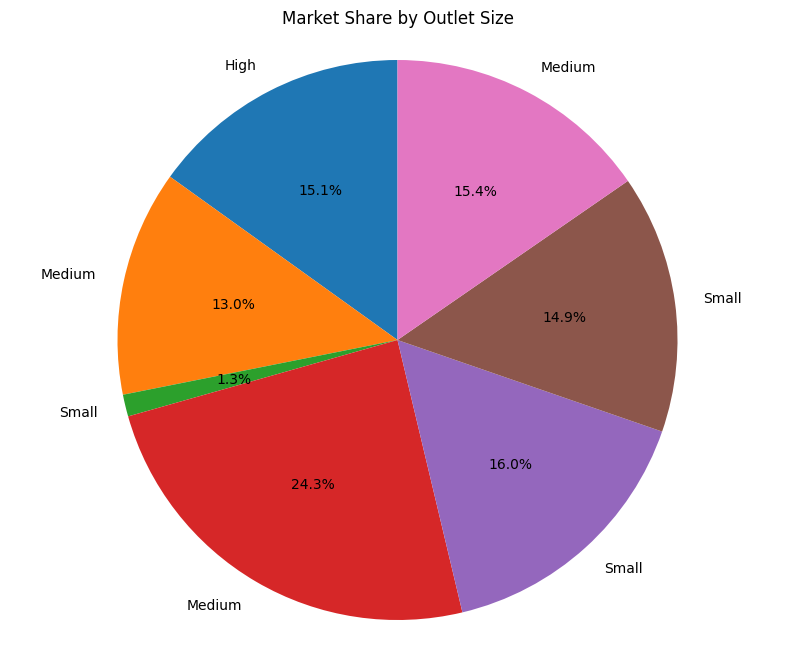

In [ ]:
# Calculate market share for 'Item_Outlet_Sales'
market_share = unique_outlet_df['Item_Outlet_Sales'] / unique_outlet_df['Item_Outlet_Sales'].sum() * 100

# Create the pie chart
plt.figure(figsize=(10, 8))
plt.pie(market_share, labels=unique_outlet_df['Outlet_Size'], autopct='%1.1f%%', startangle=90)
plt.title('Market Share by Outlet Size')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


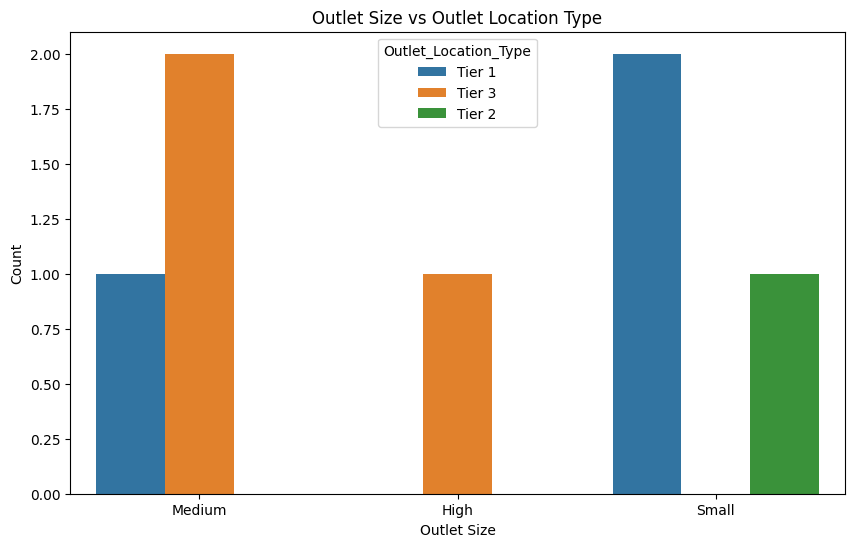

In [ ]:
# prompt: bar chart for each outlet_size column value for the count of Outlet_Location_Type

# Assuming 'df_train' is already loaded as in the previous code

plt.figure(figsize=(10, 6))
sns.countplot(x='Outlet_Size', hue='Outlet_Location_Type', data=unique_outlet_df)
plt.title('Outlet Size vs Outlet Location Type')
plt.xlabel('Outlet Size')
plt.ylabel('Count')
plt.show()


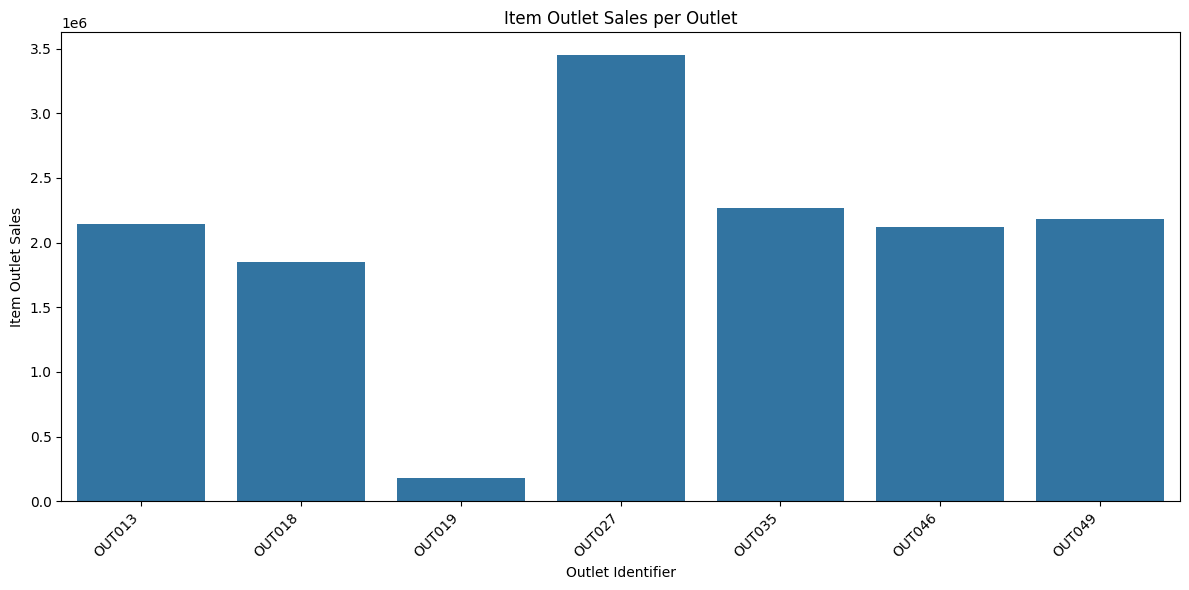

In [ ]:
# Assuming 'unique_outlet_df' is already defined as in your previous code

plt.figure(figsize=(12, 6))  # Adjust figure size as needed
sns.barplot(x='Outlet_Identifier', y='Item_Outlet_Sales', data=unique_outlet_df)
plt.title('Item Outlet Sales per Outlet')
plt.xlabel('Outlet Identifier')
plt.ylabel('Item Outlet Sales')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


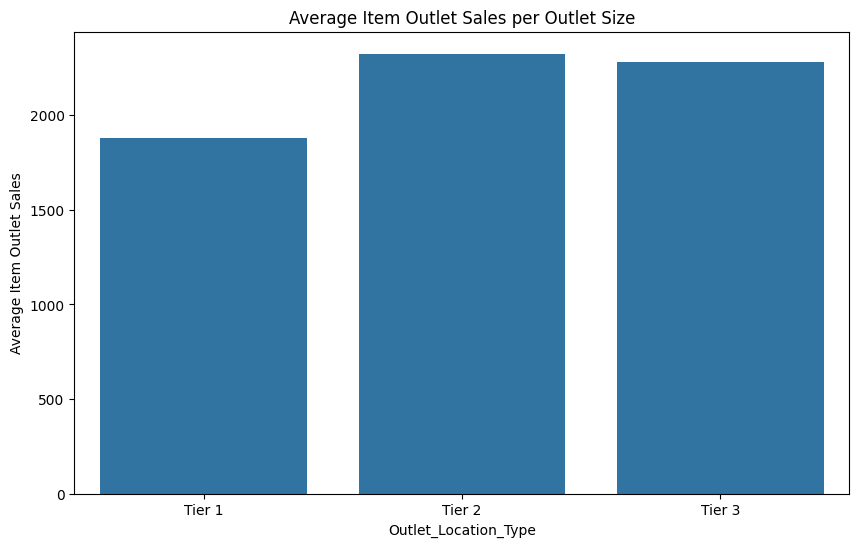

In [ ]:
# Calculate average 'Item_Outlet_Sales' for each 'Outlet_Size'
average_sales_by_size = df_train.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].mean()

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=average_sales_by_size.index, y=average_sales_by_size.values)
plt.title('Average Item Outlet Sales per Outlet Size')
plt.xlabel('Outlet_Location_Type')
plt.ylabel('Average Item Outlet Sales')
plt.show()

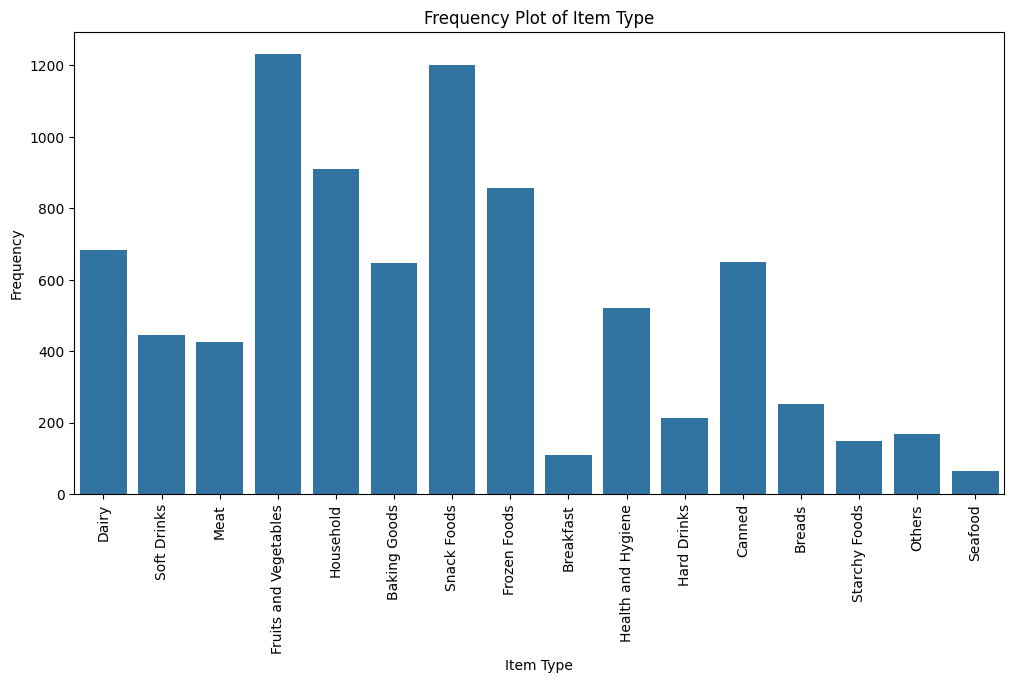

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Item_Type', data=df_train)
plt.title('Frequency Plot of Item Type')
plt.xlabel('Item Type')
plt.ylabel('Frequency')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.show()


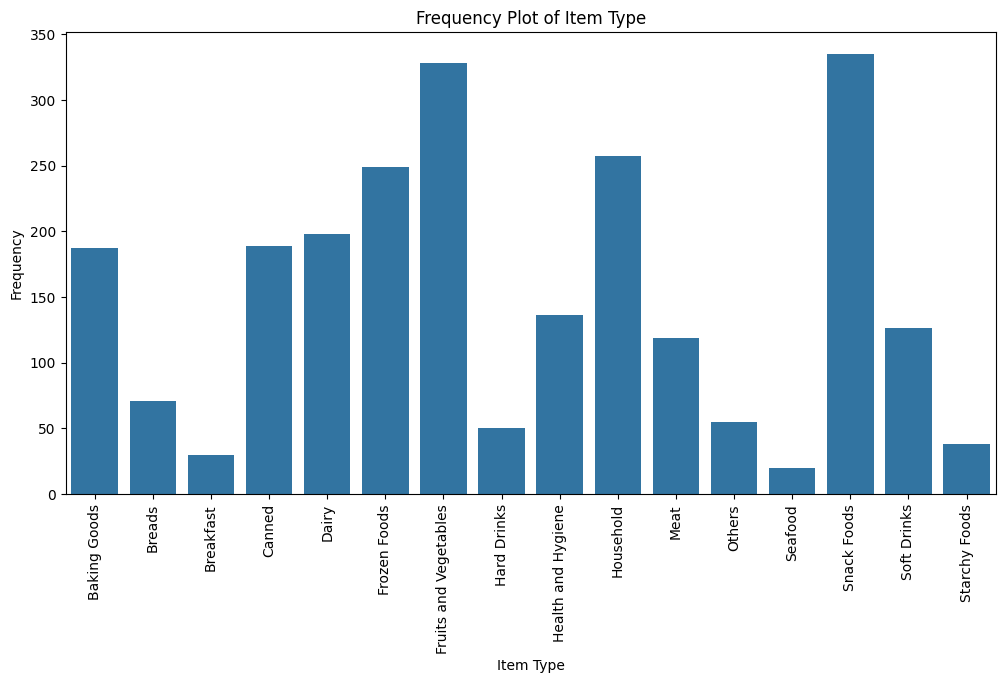

In [ ]:
plt.figure(figsize=(12, 6))
item_type_order = sorted(df_train['Item_Type'].unique()) # Get unique Item_Types and sort them
sns.countplot(x='Item_Type', data=df_train[df_train['Outlet_Size'] == 'Small'], order=item_type_order)
plt.title('Frequency Plot of Item Type')
plt.xlabel('Item Type')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()

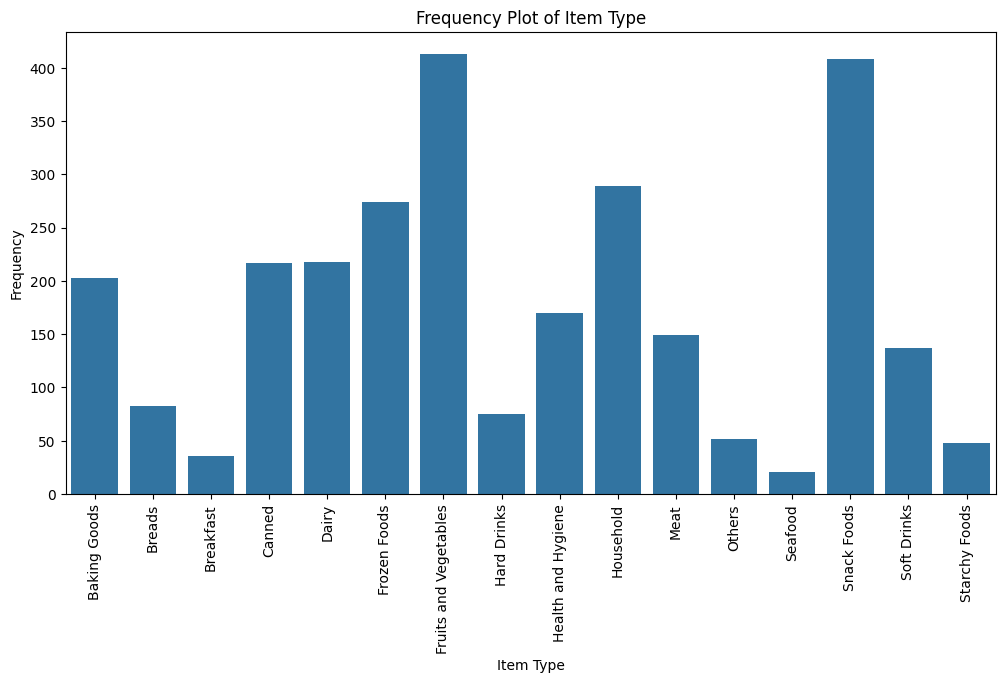

In [ ]:
plt.figure(figsize=(12, 6))
item_type_order = sorted(df_train['Item_Type'].unique()) # Get unique Item_Types and sort them
sns.countplot(x='Item_Type', data=df_train[df_train['Outlet_Size'] == 'Medium'], order=item_type_order)
plt.title('Frequency Plot of Item Type')
plt.xlabel('Item Type')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()

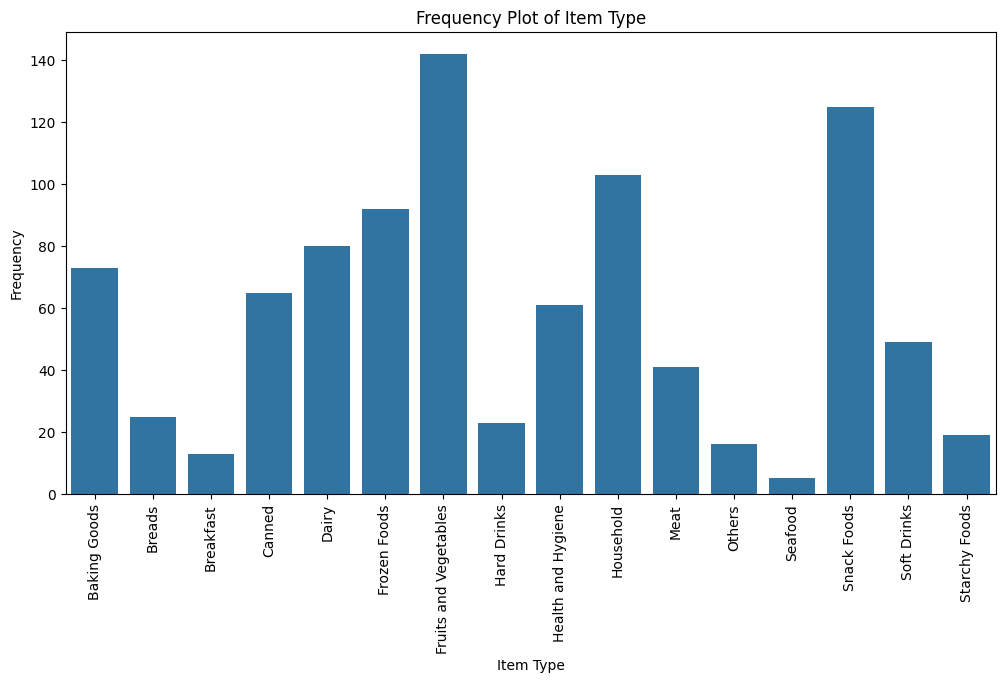

In [ ]:
plt.figure(figsize=(12, 6))
item_type_order = sorted(df_train['Item_Type'].unique()) # Get unique Item_Types and sort them
sns.countplot(x='Item_Type', data=df_train[df_train['Outlet_Size'] == 'High'], order=item_type_order)
plt.title('Frequency Plot of Item Type')
plt.xlabel('Item Type')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()

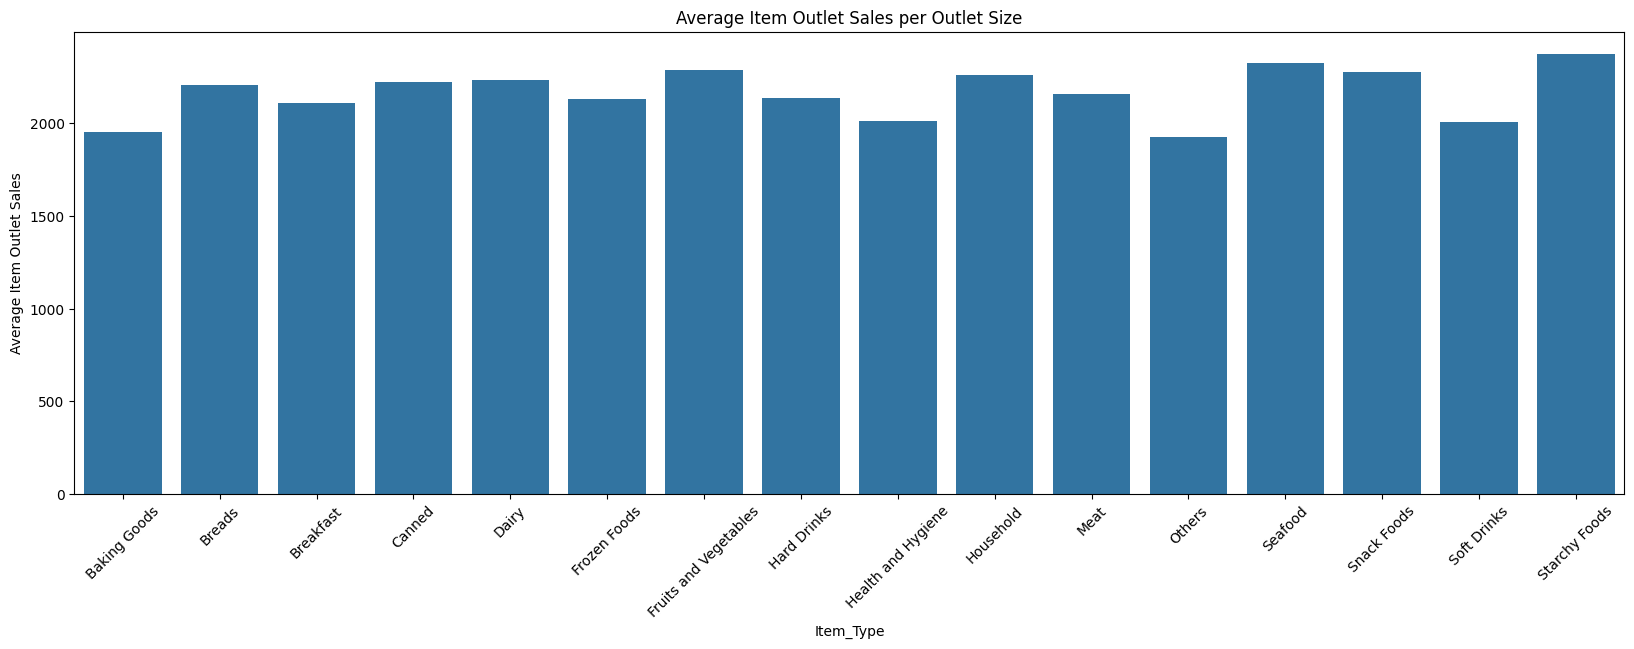

In [ ]:
# prompt: average item_outlet_sale as per outlet size plot a bar graph

# Calculate average 'Item_Outlet_Sales' for each 'Outlet_Size'
average_sales_by_size = df_train.groupby('Item_Type')['Item_Outlet_Sales'].mean()

# Create a bar plot
plt.figure(figsize=(20, 6))
sns.barplot(x=average_sales_by_size.index, y=average_sales_by_size.values)
plt.title('Average Item Outlet Sales per Outlet Size')
plt.xlabel('Item_Type')
plt.ylabel('Average Item Outlet Sales')
plt.xticks(rotation=45)
plt.show()

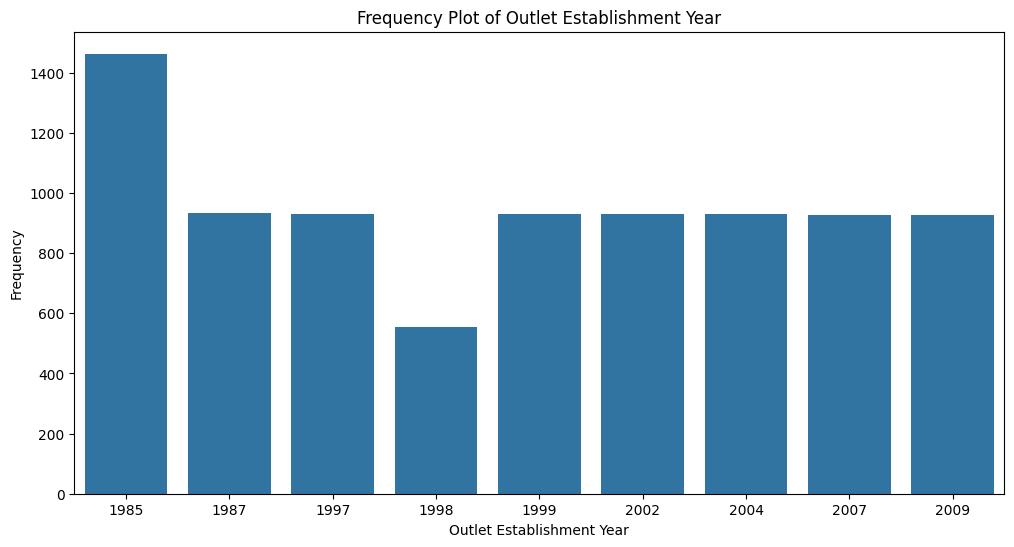

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Outlet_Establishment_Year', data=df_train)
plt.title('Frequency Plot of Outlet Establishment Year')
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Frequency')
plt.show()

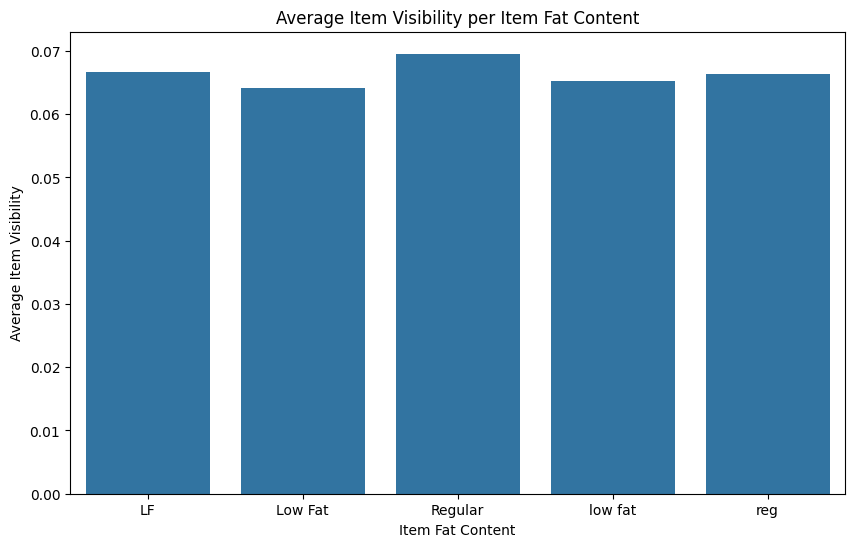

In [ ]:
# Assuming 'df_train' is already loaded as in the previous code
# Calculate average 'Item_Visibility' for each 'Item_Fat_Content'
average_visibility_by_fat = df_train.groupby('Item_Fat_Content')['Item_Visibility'].mean()

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=average_visibility_by_fat.index, y=average_visibility_by_fat.values)
plt.title('Average Item Visibility per Item Fat Content')
plt.xlabel('Item Fat Content')
plt.ylabel('Average Item Visibility')
plt.show()


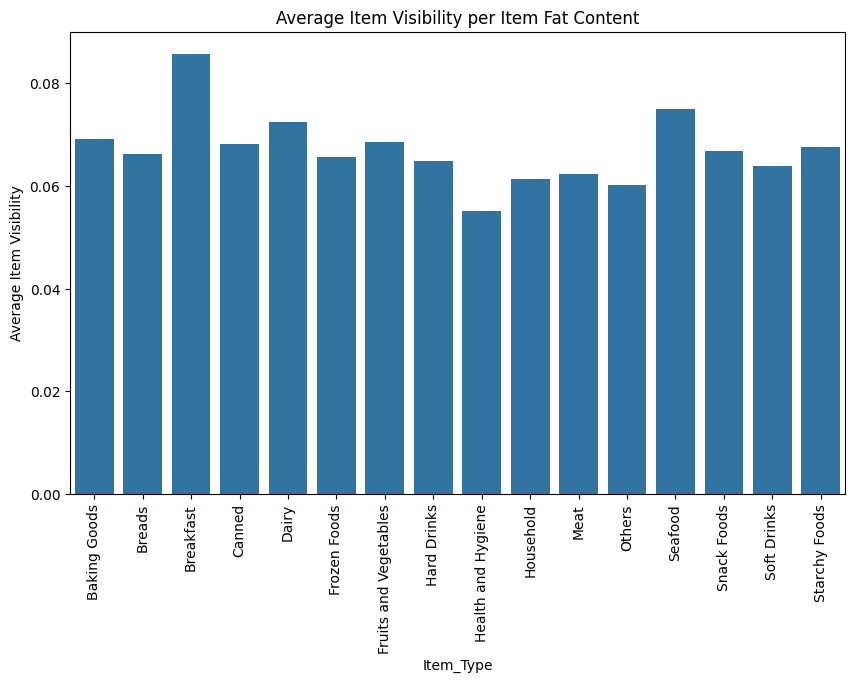

In [ ]:
# Assuming 'df_train' is already loaded as in the previous code
# Calculate average 'Item_Visibility' for each 'Item_Fat_Content'
average_visibility_by_fat = df_train.groupby('Item_Type')['Item_Visibility'].mean()

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=average_visibility_by_fat.index, y=average_visibility_by_fat.values)
plt.title('Average Item Visibility per Item Fat Content')
plt.xlabel('Item_Type')
plt.ylabel('Average Item Visibility')
plt.xticks(rotation=90)
plt.show()

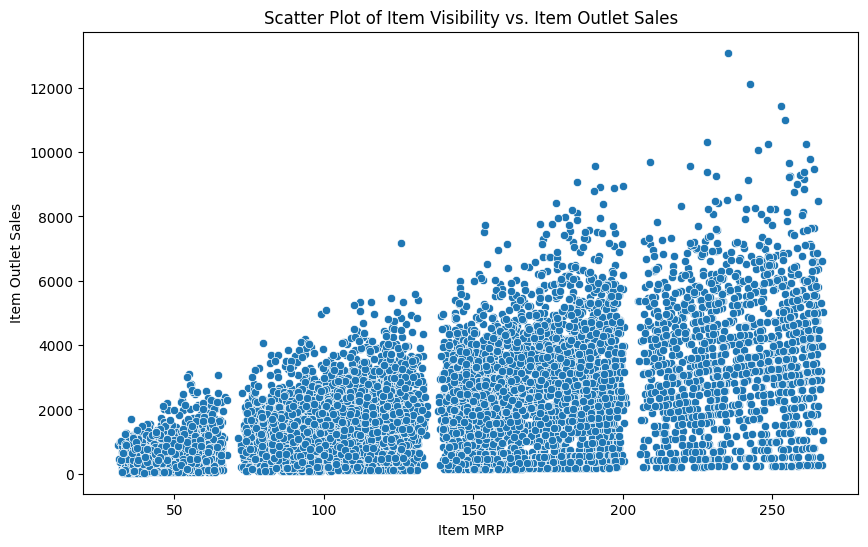

In [ ]:
# prompt: scatter plot between item visibility and item outlet sales

# Assuming 'df_train' is already loaded as in the previous code

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=df_train)
plt.title('Scatter Plot of Item Visibility vs. Item Outlet Sales')
plt.xlabel('Item MRP')
plt.ylabel('Item Outlet Sales')
plt.show()


In [ ]:
df_train.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

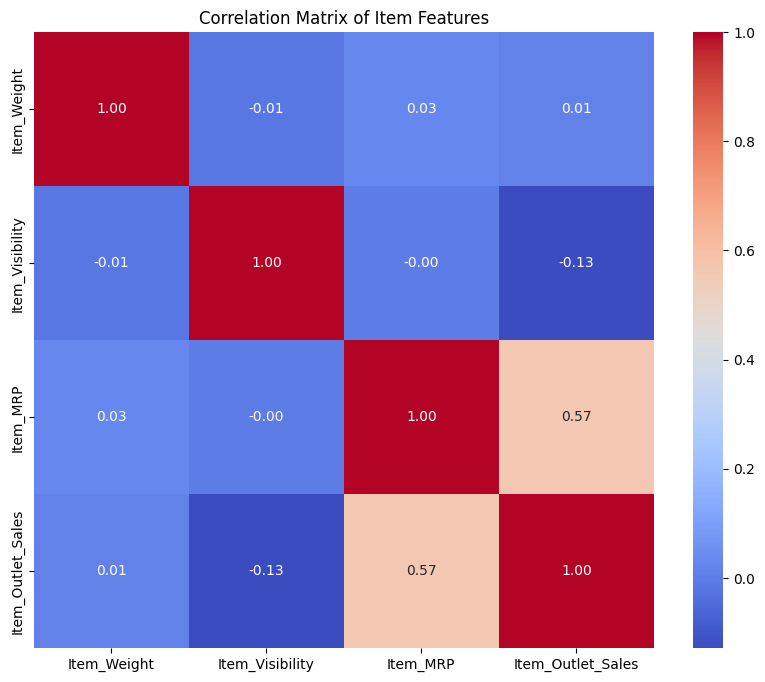

In [ ]:
# prompt: CORRELATION METRIX BETWEEN item_weight, item_visibility, item_mrp, item_outlet_sales

# Assuming 'df_train' is already loaded as in the previous code
correlation_matrix = df_train[['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Item Features')
plt.show()


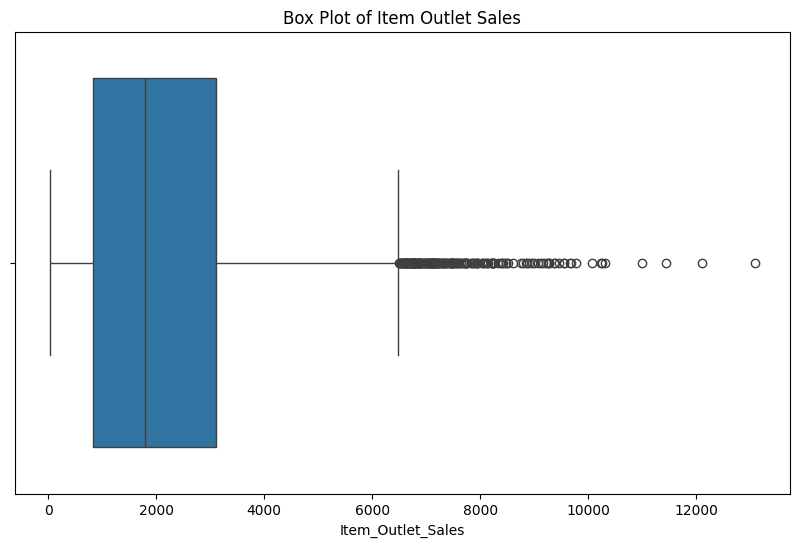

In [ ]:
# prompt: box plot for col Item_Outlet_Sales

plt.figure(figsize=(10, 6))
sns.boxplot(x='Item_Outlet_Sales', data=df_train)
plt.title('Box Plot of Item Outlet Sales')
plt.show()

<ipython-input-42-deeed7307ca5>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Item_Outlet_Sales'])


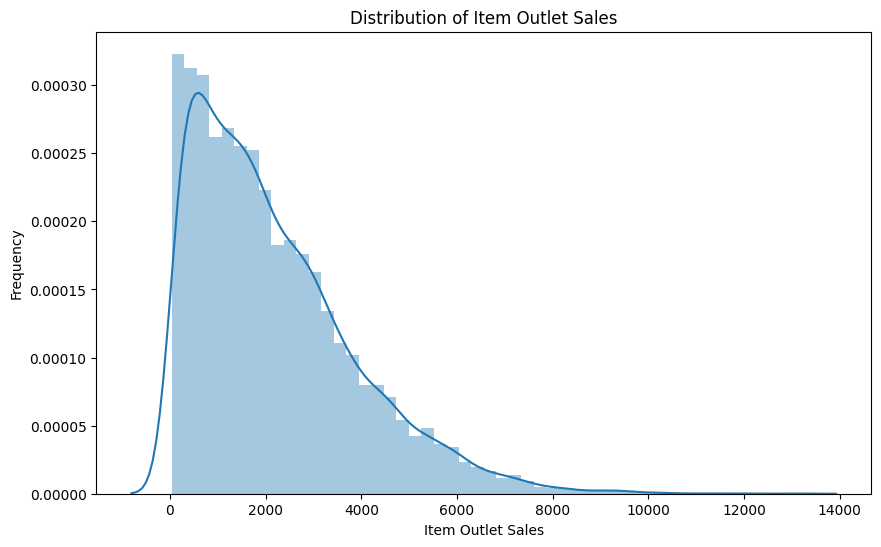

In [ ]:
# prompt: dist plot for col Item_Outlet_Sales

plt.figure(figsize=(10, 6))
sns.distplot(df_train['Item_Outlet_Sales'])
plt.title('Distribution of Item Outlet Sales')
plt.xlabel('Item Outlet Sales')
plt.ylabel('Frequency')
plt.show()

<ipython-input-38-ba979c361c65>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Item_Weight'])


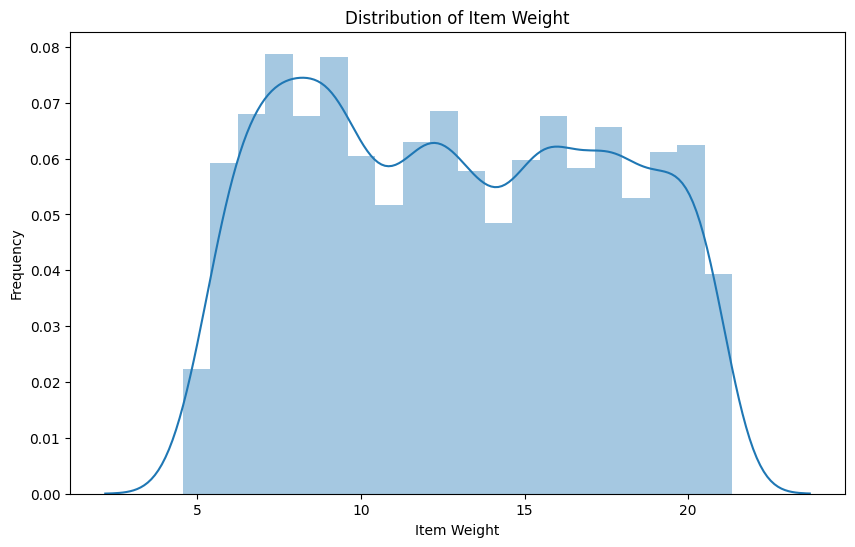

In [ ]:
plt.figure(figsize=(10, 6))
sns.distplot(df_train['Item_Weight'])
plt.title('Distribution of Item Weight')
plt.xlabel('Item Weight')
plt.ylabel('Frequency')
plt.show()

<ipython-input-39-0683d8444fe9>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Item_Visibility'])


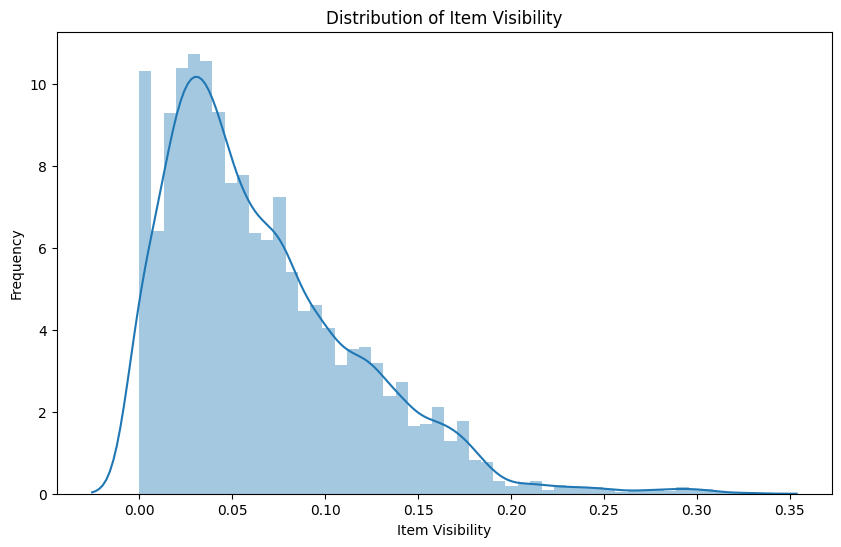

In [ ]:
plt.figure(figsize=(10, 6))
sns.distplot(df_train['Item_Visibility'])
plt.title('Distribution of Item Visibility')
plt.xlabel('Item Visibility')
plt.ylabel('Frequency')
plt.show()

<ipython-input-40-dbe676139b39>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Item_MRP'])


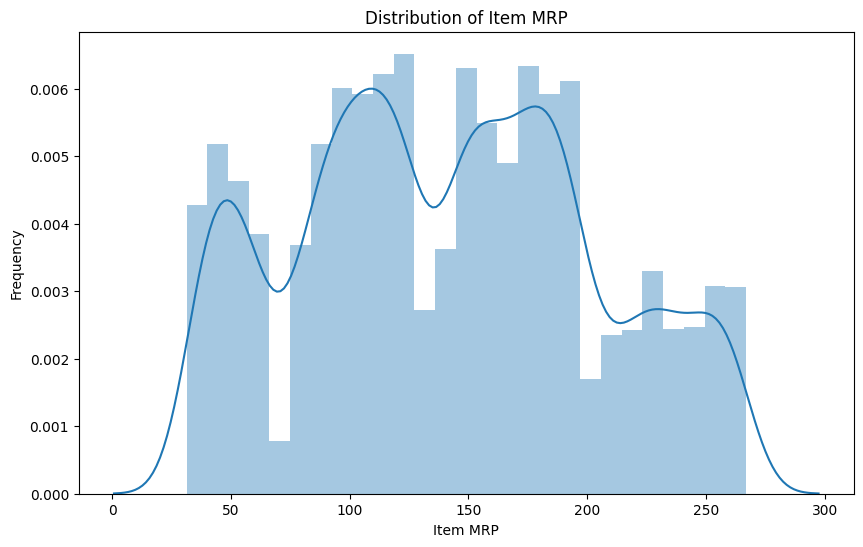

In [ ]:
plt.figure(figsize=(10, 6))
sns.distplot(df_train['Item_MRP'])
plt.title('Distribution of Item MRP')
plt.xlabel('Item MRP')
plt.ylabel('Frequency')
plt.show()